# 01 — Exploratory Data Analysis (EDA)

Notebook ini menjadi titik awal dari pipeline ML churn prediction. Tujuannya adalah memahami struktur data, distribusi variabel, pola missing values, serta menyiapkan data agar siap digunakan pada tahap preprocessing dan modeling.

**Dataset:** `dataset/telecom_customer_churn.csv`
**Target:** `Customer Status` -> binary: Churned (1) vs Not Churned (0)

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("Libraries loaded.")

Libraries loaded.


## 2. Baca Dataset

Dataset dimuat dari folder `dataset/` yang berada satu level di atas folder `notebooks/`.

In [2]:
df = pd.read_csv("../dataset/telecom_customer_churn.csv")

print(f"Shape: {df.shape[0]:,} baris x {df.shape[1]} kolom")
df.head()

Shape: 7,043 baris x 38 kolom


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


## 3. Informasi Dasar Dataset

Langkah ini mengidentifikasi tipe data setiap kolom, jumlah non-null values, dan statistik deskriptif.

In [3]:
print("=== df.info() ===")
df.info()

=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   str    
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   str    
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null 

### 3.1 Statistik Deskriptif

Melihat mean, std, min, max untuk mendeteksi rentang nilai ekstrem atau distribusi yang skewed.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,7043.0,46.509726,16.750352,19.000000,32.000000,46.000000,60.000000,80.000000
Number of Dependents,7043.0,0.468692,0.962802,0.000000,0.000000,0.000000,0.000000,9.000000
Zip Code,7043.0,93486.070567,1856.767505,90001.000000,92101.000000,93518.000000,95329.000000,96150.000000
Latitude,7043.0,36.197455,2.468929,32.555828,33.990646,36.205465,38.161321,41.962127
Longitude,7043.0,-119.756684,2.154425,-124.301372,-121.788090,-119.595293,-117.969795,-114.192901
Number of Referrals,7043.0,1.951867,3.001199,0.000000,0.000000,0.000000,3.000000,11.000000
Tenure in Months,7043.0,32.386767,24.542061,1.000000,9.000000,29.000000,55.000000,72.000000
Avg Monthly Long Distance Charges,6361.0,25.420517,14.200374,1.010000,13.050000,25.690000,37.680000,49.990000
Avg Monthly GB Download,5517.0,26.189958,19.586585,2.000000,13.000000,21.000000,30.000000,85.000000
Monthly Charge,7043.0,63.596131,31.204743,-10.000000,30.400000,70.050000,89.750000,118.750000


### 3.2 Pengecekan Missing Values

Missing values pada kolom internet-related terjadi karena pelanggan tidak berlangganan internet, bukan karena error.

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({"Missing Count": missing, "Missing (%)": missing_pct})
print(missing_df.to_string())

                                   Missing Count  Missing (%)
Churn Category                              5174        73.46
Churn Reason                                5174        73.46
Offer                                       3877        55.05
Online Security                             1526        21.67
Online Backup                               1526        21.67
Avg Monthly GB Download                     1526        21.67
Internet Type                               1526        21.67
Streaming Movies                            1526        21.67
Streaming TV                                1526        21.67
Device Protection Plan                      1526        21.67
Premium Tech Support                        1526        21.67
Unlimited Data                              1526        21.67
Streaming Music                             1526        21.67
Avg Monthly Long Distance Charges            682         9.68
Multiple Lines                               682         9.68


### 3.3 Pengecekan Duplikasi

Baris duplikat dapat menyebabkan bias pada model.

In [6]:
dup_rows = df.duplicated().sum()
dup_ids  = df["Customer ID"].duplicated().sum()

print(f"Baris duplikat penuh : {dup_rows}")
print(f"Customer ID duplikat : {dup_ids}")

Baris duplikat penuh : 0
Customer ID duplikat : 0


## 4. Distribusi Variabel Target

Kita definisikan target binary: Churned = 1, Not Churned = 0. Distribusi kelas menentukan apakah perlu strategi penanganan imbalance saat modeling.

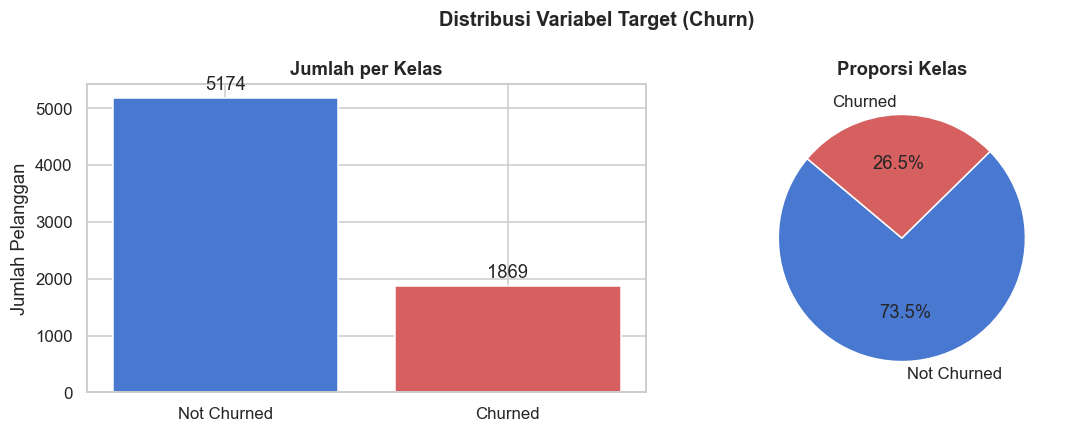

Churn rate: 26.5%


In [7]:
df["Churn"] = (df["Customer Status"] == "Churned").astype(int)
churn_counts = df["Churn"].value_counts().rename({0: "Not Churned", 1: "Churned"})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=[sns.color_palette("muted")[0], sns.color_palette("muted")[3]])
axes[0].bar_label(bars, padding=3)
axes[0].set_title("Jumlah per Kelas", fontweight="bold")
axes[0].set_ylabel("Jumlah Pelanggan")

axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct="%1.1f%%",
            colors=[sns.color_palette("muted")[0], sns.color_palette("muted")[3]],
            startangle=140)
axes[1].set_title("Proporsi Kelas", fontweight="bold")

plt.suptitle("Distribusi Variabel Target (Churn)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("target_distribution.png", bbox_inches="tight")
plt.show()

print(f"Churn rate: {df["Churn"].mean()*100:.1f}%")

## 5. Matriks Korelasi Fitur Numerik

Heatmap korelasi Pearson menunjukkan hubungan antar fitur numerik dan terhadap target Churn.

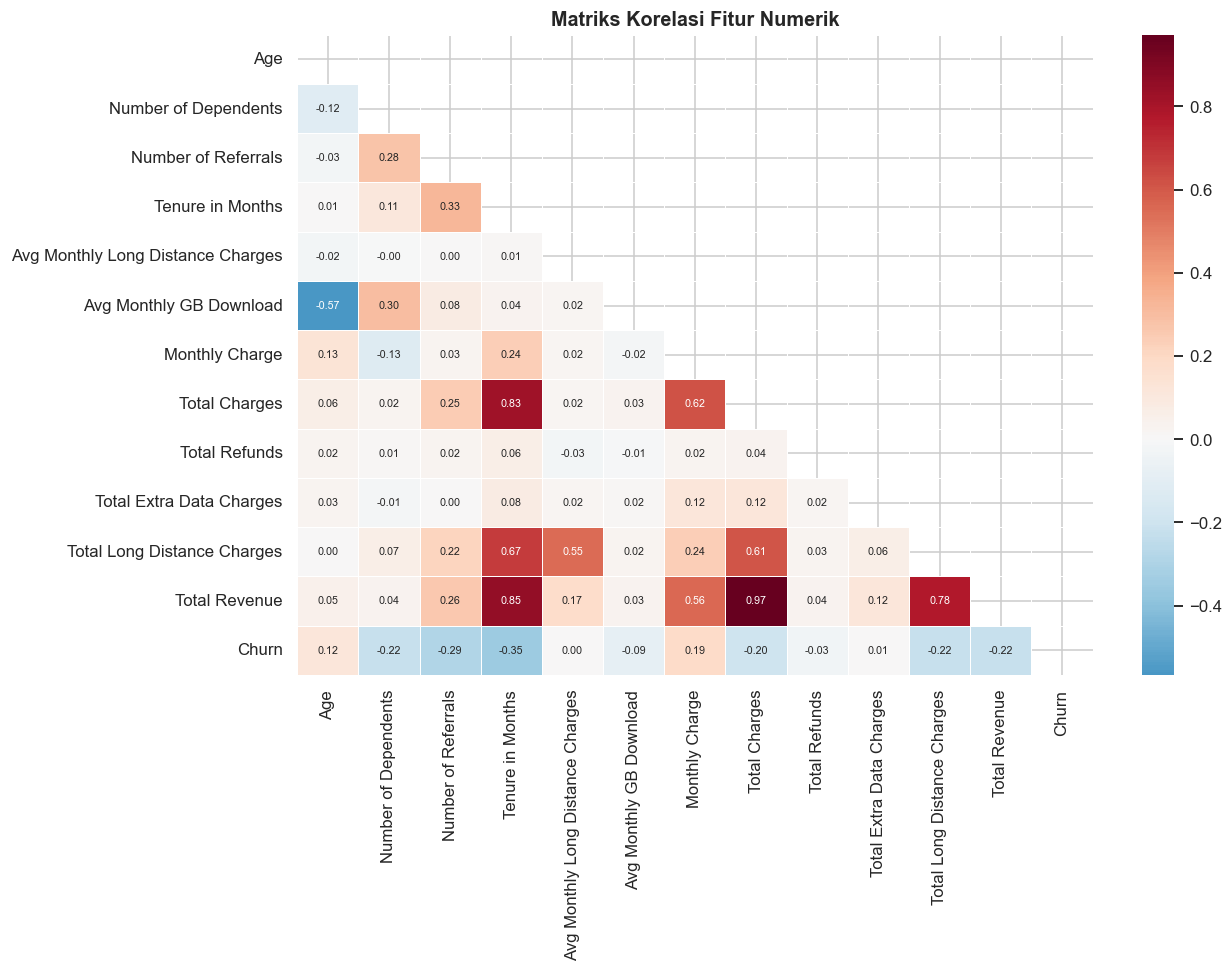

In [8]:
num_cols = df.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c not in ["Latitude", "Longitude", "Zip Code"]]

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.4, ax=ax, annot_kws={"size": 7})
ax.set_title("Matriks Korelasi Fitur Numerik", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_matrix.png", bbox_inches="tight")
plt.show()

### 5.1 Korelasi Fitur terhadap Target Churn

Kita isolasi korelasi masing-masing fitur numerik terhadap kolom Churn.

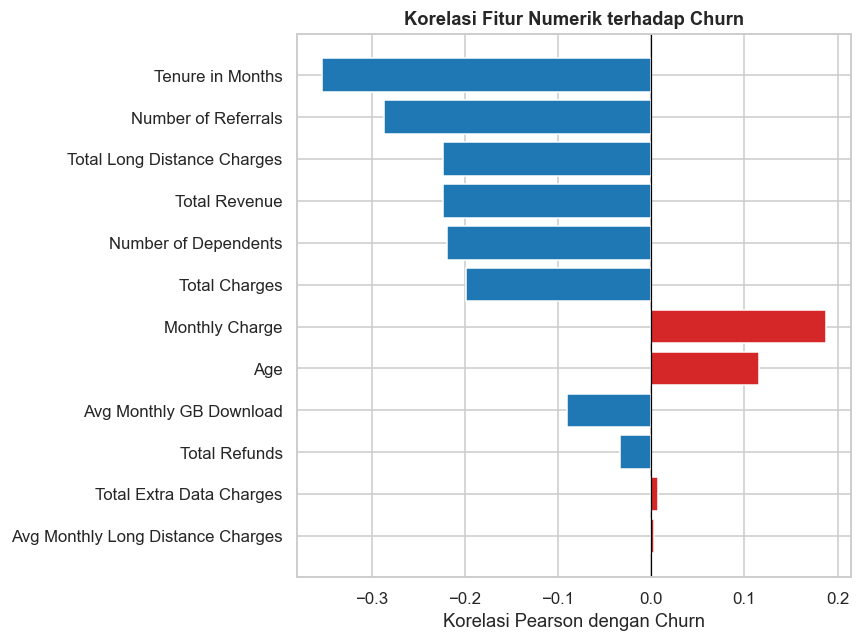

In [9]:
churn_corr = corr["Churn"].drop("Churn").sort_values(key=abs, ascending=True)
colors = ["#d62728" if v > 0 else "#1f77b4" for v in churn_corr]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(churn_corr.index, churn_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Korelasi Pearson dengan Churn")
ax.set_title("Korelasi Fitur Numerik terhadap Churn", fontweight="bold")
plt.tight_layout()
plt.savefig("churn_correlation.png", bbox_inches="tight")
plt.show()

## 6. Penanganan Missing Values

Strategi berdasarkan penyebab:
- Internet-related (~21.7% missing): isi dengan No / 0
- Phone-related (~9.7% missing): isi dengan No / median
- Offer (~55% missing): isi dengan No Offer
- Churn Reason / Churn Category: di-drop (post-churn leakage)

In [10]:
df_clean = df.copy()

internet_cols = [
    "Internet Type", "Avg Monthly GB Download", "Online Security",
    "Online Backup", "Device Protection Plan", "Premium Tech Support",
    "Streaming TV", "Streaming Movies", "Streaming Music", "Unlimited Data"
]

for col in internet_cols:
    if df_clean[col].dtype == "object":
        df_clean[col] = df_clean[col].fillna("No")
    else:
        df_clean[col] = df_clean[col].fillna(0)

df_clean["Multiple Lines"] = df_clean["Multiple Lines"].fillna("No")
df_clean["Avg Monthly Long Distance Charges"] = df_clean["Avg Monthly Long Distance Charges"].fillna(
    df_clean["Avg Monthly Long Distance Charges"].median()
)
df_clean["Offer"] = df_clean["Offer"].fillna("No Offer")

remaining = df_clean.drop(columns=["Churn Reason", "Churn Category"]).isnull().sum()
remaining = remaining[remaining > 0]
print("Sisa missing values (excluding leakage columns):")
print(remaining if len(remaining) > 0 else "Tidak ada -- semua missing values telah ditangani.")

Sisa missing values (excluding leakage columns):
Tidak ada -- semua missing values telah ditangani.


## 7. Encoding Fitur Kategorikal

Model ML membutuhkan input numerik:
- Label Encoding untuk fitur binary (2 nilai unik)
- One-Hot Encoding untuk fitur dengan lebih dari 2 nilai unik

Kolom identifikasi dan leakage di-drop terlebih dahulu.

In [11]:
drop_cols = ["Customer ID", "City", "Latitude", "Longitude", "Zip Code",
             "Customer Status", "Churn Reason", "Churn Category"]
df_encoded = df_clean.drop(columns=drop_cols)

cat_cols = df_encoded.select_dtypes(include="object").columns.tolist()
print(f"Kolom kategorikal yang akan di-encode ({len(cat_cols)}):")
print(cat_cols)

Kolom kategorikal yang akan di-encode (18):
['Gender', 'Married', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method']


In [12]:
binary_cols = [c for c in cat_cols if df_encoded[c].nunique() == 2]
for col in binary_cols:
    vals = df_encoded[col].unique()
    df_encoded[col] = df_encoded[col].map({vals[0]: 0, vals[1]: 1})

print(f"Label encoded ({len(binary_cols)}): {binary_cols}")

multi_cols = [c for c in cat_cols if c not in binary_cols]
df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, drop_first=True)

print(f"One-hot encoded ({len(multi_cols)}): {multi_cols}")
print(f"\nShape setelah encoding: {df_encoded.shape}")
df_encoded.head()

Label encoded (6): ['Gender', 'Married', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Paperless Billing']
One-hot encoded (12): ['Offer', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Payment Method']

Shape setelah encoding: (7043, 47)


,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,Streaming Movies_No,Streaming Movies_Yes,Streaming Music_No,Streaming Music_Yes,Unlimited Data_No,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Payment Method_Credit Card,Payment Method_Mailed Check
0,0,37,0,0,2,9,0,42.39,0,0,...,True,False,True,False,False,True,True,False,True,False
1,1,46,1,0,0,9,0,10.69,1,0,...,False,True,False,True,True,False,False,False,True,False
2,1,50,1,0,0,4,0,33.65,0,0,...,True,False,True,False,False,True,False,False,False,False
3,1,78,0,0,1,13,0,27.82,0,0,...,False,True,True,False,False,True,False,False,False,False
4,0,75,0,0,3,3,0,7.38,0,0,...,True,False,True,False,False,True,False,False,True,False


## 8. Simpan Dataset yang Sudah Diproses

Dataset hasil EDA dan preprocessing awal disimpan ke dataset/ agar dapat digunakan pada notebook modeling.

In [13]:
df_encoded.to_csv("../dataset/telecom_churn_processed.csv", index=False)

print("Dataset tersimpan: ../dataset/telecom_churn_processed.csv")
print(f"Final shape : {df_encoded.shape[0]:,} baris x {df_encoded.shape[1]} kolom")
print(f"Churn rate  : {df_encoded["Churn"].mean()*100:.1f}%")

Dataset tersimpan: ../dataset/telecom_churn_processed.csv
Final shape : 7,043 baris x 47 kolom
Churn rate  : 26.5%


## 9. Ringkasan Temuan EDA

In [14]:
top_corr = churn_corr.abs().sort_values(ascending=False).head(5)

print("=" * 60)
print("RINGKASAN TEMUAN EDA")
print("=" * 60)
print(f"Total pelanggan        : {len(df):,}")
print(f"Total fitur awal       : {df.shape[1]}")
print(f"Baris duplikat         : {dup_rows}")
print(f"Customer ID duplikat   : {dup_ids}")
print(f"Churn rate             : {df["Churn"].mean()*100:.1f}% (dataset imbalanced)")
print()
print("Missing values -- strategi:")
print("  Internet-related cols : diisi No / 0")
print("  Phone-related cols    : diisi No / median")
print("  Offer                 : diisi No Offer")
print("  Churn Reason/Category : di-drop (leakage)")
print()
print("Top 5 fitur numerik berkorelasi dengan Churn:")
for feat, val in top_corr.items():
    direction = "positif" if churn_corr[feat] > 0 else "negatif"
    print(f"  {feat:<42} r = {churn_corr[feat]:+.3f} ({direction})")
print()
print(f"Shape final: {df_encoded.shape[0]:,} baris x {df_encoded.shape[1]} kolom")

RINGKASAN TEMUAN EDA
Total pelanggan        : 7,043
Total fitur awal       : 39
Baris duplikat         : 0
Customer ID duplikat   : 0
Churn rate             : 26.5% (dataset imbalanced)

Missing values -- strategi:
  Internet-related cols : diisi No / 0
  Phone-related cols    : diisi No / median
  Offer                 : diisi No Offer
  Churn Reason/Category : di-drop (leakage)

Top 5 fitur numerik berkorelasi dengan Churn:
  Tenure in Months                           r = -0.353 (negatif)
  Number of Referrals                        r = -0.287 (negatif)
  Total Long Distance Charges                r = -0.224 (negatif)
  Total Revenue                              r = -0.223 (negatif)
  Number of Dependents                       r = -0.219 (negatif)

Shape final: 7,043 baris x 47 kolom


## 10. Modeling — Train/Test Split

Kita bagi dataset yang sudah diproses menjadi training set (80%) dan testing set (20%) dengan stratifikasi pada kolom `Churn` agar proporsi kelas tetap seimbang di kedua subset.

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_model = pd.read_csv("../dataset/telecom_churn_processed.csv")

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} baris ({y_train.mean()*100:.1f}% churn)")
print(f"Testing set  : {X_test.shape[0]:,} baris ({y_test.mean()*100:.1f}% churn)")
print(f"Fitur        : {X_train.shape[1]} kolom")

Training set : 5,634 baris (26.5% churn)
Testing set  : 1,409 baris (26.5% churn)
Fitur        : 46 kolom


## 11. Baseline — Random Forest vs XGBoost

Kita latih dua algoritma sebagai pembanding:
- **Random Forest** dengan `class_weight='balanced'` untuk menangani imbalance
- **XGBoost** dengan `scale_pos_weight` yang dihitung dari rasio kelas

Keduanya dilatih dengan parameter default sebelum tuning.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from xgboost import XGBClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight untuk XGBoost: {scale_pos:.2f}")

rf = RandomForestClassifier(
    n_estimators=200, class_weight="balanced",
    random_state=42, n_jobs=-1
)
xgb = XGBClassifier(
    n_estimators=200, scale_pos_weight=scale_pos,
    eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0
)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
print("\nKedua model selesai dilatih.")

scale_pos_weight untuk XGBoost: 2.77



Kedua model selesai dilatih.


### 11.1 Evaluasi pada Testing Set

Metrik utama: **F1-Score weighted** (memperhitungkan imbalance) dan **ROC-AUC** (kemampuan diskriminasi). Classification report memberikan detail per kelas.

In [17]:
def evaluate(name, model, X, y):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]
    auc  = roc_auc_score(y, prob)
    f1   = f1_score(y, pred, average="weighted")
    print(f"=== {name} ===")
    print(classification_report(y, pred, target_names=["Not Churned", "Churned"]))
    print(f"ROC-AUC  : {auc:.4f}")
    print(f"F1 (wtd) : {f1:.4f}\n")
    return {"model": name, "roc_auc": auc, "f1_weighted": f1}

res_rf  = evaluate("Random Forest", rf,  X_test, y_test)
res_xgb = evaluate("XGBoost",       xgb, X_test, y_test)

=== Random Forest ===
              precision    recall  f1-score   support

 Not Churned       0.85      0.92      0.89      1035
     Churned       0.72      0.56      0.63       374

    accuracy                           0.82      1409
   macro avg       0.79      0.74      0.76      1409
weighted avg       0.82      0.82      0.82      1409

ROC-AUC  : 0.8862
F1 (wtd) : 0.8169



=== XGBoost ===
              precision    recall  f1-score   support

 Not Churned       0.89      0.88      0.88      1035
     Churned       0.67      0.70      0.69       374

    accuracy                           0.83      1409
   macro avg       0.78      0.79      0.78      1409
weighted avg       0.83      0.83      0.83      1409

ROC-AUC  : 0.8821
F1 (wtd) : 0.8308



## 12. 5-Fold Cross Validation

Cross-validation memberikan estimasi performa yang lebih stabil. Kita gunakan `StratifiedKFold` agar distribusi kelas terjaga di setiap fold, dan evaluasi dengan ROC-AUC serta F1-Score weighted.

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["roc_auc", "f1_weighted"]

print("Menjalankan 5-fold CV untuk kedua model...")
cv_rf  = cross_validate(rf,  X, y, cv=cv, scoring=scoring, n_jobs=-1)
cv_xgb = cross_validate(xgb, X, y, cv=cv, scoring=scoring, n_jobs=-1)

results = []
for name, cv_res in [("Random Forest", cv_rf), ("XGBoost", cv_xgb)]:
    results.append({
        "Model"   : name,
        "AUC Mean": round(cv_res["test_roc_auc"].mean(), 4),
        "AUC Std" : round(cv_res["test_roc_auc"].std(), 4),
        "F1 Mean" : round(cv_res["test_f1_weighted"].mean(), 4),
        "F1 Std"  : round(cv_res["test_f1_weighted"].std(), 4),
    })

cv_df = pd.DataFrame(results).set_index("Model")
print(cv_df.to_string())

winner = cv_df["AUC Mean"].idxmax()
print(f"\nModel dengan CV AUC tertinggi: {winner}")

Menjalankan 5-fold CV untuk kedua model...


               AUC Mean  AUC Std  F1 Mean  F1 Std
Model                                            
Random Forest    0.8912   0.0056   0.8274  0.0017
XGBoost          0.8926   0.0082   0.8341  0.0066

Model dengan CV AUC tertinggi: XGBoost


## 13. Hyperparameter Tuning — RandomizedSearchCV

Kita lakukan tuning pada model terbaik (berdasarkan CV AUC) menggunakan `RandomizedSearchCV` dengan 50 iterasi. Ini lebih efisien dari GridSearchCV karena menyampling kombinasi parameter secara acak dari distribusi yang lebar.

In [19]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    "n_estimators"     : [100, 200, 300, 500],
    "max_depth"        : [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4],
    "max_features"     : ["sqrt", "log2", 0.3, 0.5],
}
xgb_param_dist = {
    "n_estimators"    : [100, 200, 300, 500],
    "max_depth"       : [3, 4, 5, 6, 8],
    "learning_rate"   : [0.01, 0.05, 0.1, 0.2],
    "subsample"       : [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma"           : [0, 0.1, 0.5, 1],
    "reg_alpha"       : [0, 0.1, 1],
    "reg_lambda"      : [1, 2, 5],
}

if winner == "Random Forest":
    base_model = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
    param_dist  = rf_param_dist
else:
    base_model = XGBClassifier(scale_pos_weight=scale_pos, eval_metric="logloss",
                               random_state=42, n_jobs=-1, verbosity=0)
    param_dist  = xgb_param_dist

search = RandomizedSearchCV(
    base_model, param_distributions=param_dist,
    n_iter=50, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc", random_state=42, n_jobs=-1, verbose=1,
)

print(f"Tuning {winner} — 50 iterasi x 5-fold CV...")
search.fit(X_train, y_train)

print(f"\nBest CV AUC : {search.best_score_:.4f}")
print("Best params :")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Tuning XGBoost — 50 iterasi x 5-fold CV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits



Best CV AUC : 0.9093
Best params :
  subsample: 1.0
  reg_lambda: 1
  reg_alpha: 1
  n_estimators: 200
  max_depth: 3
  learning_rate: 0.05
  gamma: 0.1
  colsample_bytree: 0.6


### 13.1 Evaluasi Model Setelah Tuning

Bandingkan performa sebelum dan sesudah tuning pada testing set.

In [20]:
best_model = search.best_estimator_

pred_tuned = best_model.predict(X_test)
prob_tuned = best_model.predict_proba(X_test)[:, 1]

auc_tuned = roc_auc_score(y_test, prob_tuned)
f1_tuned  = f1_score(y_test, pred_tuned, average="weighted")

base_auc = res_rf["roc_auc"] if winner == "Random Forest" else res_xgb["roc_auc"]
base_f1  = res_rf["f1_weighted"] if winner == "Random Forest" else res_xgb["f1_weighted"]

print(f"=== {winner} — Setelah Tuning ===")
print(classification_report(y_test, pred_tuned, target_names=["Not Churned", "Churned"]))
print(f"ROC-AUC  : {auc_tuned:.4f}  (baseline: {base_auc:.4f}  delta: {auc_tuned - base_auc:+.4f})")
print(f"F1 (wtd) : {f1_tuned:.4f}  (baseline: {base_f1:.4f}  delta: {f1_tuned - base_f1:+.4f})")

=== XGBoost — Setelah Tuning ===
              precision    recall  f1-score   support

 Not Churned       0.94      0.79      0.85      1035
     Churned       0.59      0.85      0.70       374

    accuracy                           0.80      1409
   macro avg       0.76      0.82      0.77      1409
weighted avg       0.84      0.80      0.81      1409

ROC-AUC  : 0.9027  (baseline: 0.8821  delta: +0.0206)
F1 (wtd) : 0.8120  (baseline: 0.8308  delta: -0.0188)


## 14. Simpan Model Terbaik

Model terbaik hasil tuning disimpan ke `models/best_model.pkl` menggunakan `pickle`, siap digunakan di notebook evaluasi atau deployment.

In [21]:
import pickle
import os

os.makedirs("../models", exist_ok=True)
model_path = "../models/best_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

size_kb = os.path.getsize(model_path) / 1024
print(f"Model tersimpan : {model_path}")
print(f"Tipe model      : {type(best_model).__name__}")
print(f"Ukuran file     : {size_kb:.1f} KB")

Model tersimpan : ../models/best_model.pkl
Tipe model      : XGBClassifier
Ukuran file     : 232.3 KB


## 15. Ringkasan Hasil Modeling

Perbandingan lengkap semua model yang dilatih pada notebook ini.

In [22]:
print("=" * 72)
print("RINGKASAN HASIL MODELING")
print("=" * 72)
print(f"{'Model':<26} {'AUC CV':>8} {'F1 CV':>8} {'AUC Test':>10} {'F1 Test':>9}")
print("-" * 72)
print(f"{'Random Forest (baseline)':<26} {cv_df.loc['Random Forest','AUC Mean']:>8.4f} {cv_df.loc['Random Forest','F1 Mean']:>8.4f} {res_rf['roc_auc']:>10.4f} {res_rf['f1_weighted']:>9.4f}")
print(f"{'XGBoost (baseline)':<26} {cv_df.loc['XGBoost','AUC Mean']:>8.4f} {cv_df.loc['XGBoost','F1 Mean']:>8.4f} {res_xgb['roc_auc']:>10.4f} {res_xgb['f1_weighted']:>9.4f}")
print(f"{'Best model (tuned)' + ' *':<26} {'—':>8} {'—':>8} {auc_tuned:>10.4f} {f1_tuned:>9.4f}")
print("-" * 72)
print(f"\n* Model terbaik : {winner} (setelah RandomizedSearchCV)")
print(f"  Tersimpan di  : models/best_model.pkl")

RINGKASAN HASIL MODELING
Model                        AUC CV    F1 CV   AUC Test   F1 Test
------------------------------------------------------------------------
Random Forest (baseline)     0.8912   0.8274     0.8862    0.8169
XGBoost (baseline)           0.8926   0.8341     0.8821    0.8308
Best model (tuned) *              —        —     0.9027    0.8120
------------------------------------------------------------------------

* Model terbaik : XGBoost (setelah RandomizedSearchCV)
  Tersimpan di  : models/best_model.pkl


## 16. Feature Importance

Kita visualisasikan 10 fitur paling berpengaruh dari model XGBoost terbaik hasil tuning. XGBoost menyediakan tiga jenis importance:
- **weight** — berapa kali fitur digunakan sebagai split point
- **gain** — rata-rata gain (penurunan impurity) ketika fitur digunakan
- **cover** — rata-rata jumlah sampel yang terpengaruh oleh split pada fitur tersebut

Kita tampilkan ketiganya untuk perspektif yang lebih lengkap, dan highlight **gain** sebagai metrik utama karena paling mencerminkan kontribusi prediktif nyata.

In [23]:
import pickle
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# Load model dan data
with open("../models/best_model.pkl", "rb") as f:
    best_model = pickle.load(f)

df_model = pd.read_csv("../dataset/telecom_churn_processed.csv")
feature_names = df_model.drop(columns=["Churn"]).columns.tolist()

print(f"Model loaded: {type(best_model).__name__}")
print(f"Total fitur : {len(feature_names)}")

Model loaded: XGBClassifier


Total fitur : 46


### 16.1 Top 10 Feature Importance — Gain (Utama)

**Gain** mengukur rata-rata penurunan loss function saat fitur digunakan sebagai split. Fitur dengan gain tinggi berkontribusi paling besar dalam membedakan pelanggan churn vs tidak.

In [24]:
booster = best_model.get_booster()

def get_importance_df(importance_type, feature_names, top_n=10):
    scores = booster.get_score(importance_type=importance_type)
    # XGBoost uses f0, f1, ... internally — map back to feature names
    idx_to_name = {f"f{i}": name for i, name in enumerate(feature_names)}
    named = {idx_to_name.get(k, k): v for k, v in scores.items()}
    df = pd.DataFrame(named.items(), columns=["Feature", importance_type])
    df = df.sort_values(importance_type, ascending=False).head(top_n).reset_index(drop=True)
    # Normalise to 0-100 for readability
    df[importance_type] = df[importance_type] / df[importance_type].sum() * 100
    return df

df_gain  = get_importance_df("gain",   feature_names)
df_weight= get_importance_df("weight", feature_names)
df_cover = get_importance_df("cover",  feature_names)

print("Top 10 Features by Gain (normalised %):")
print(df_gain.to_string(index=False))

Top 10 Features by Gain (normalised %):
                   Feature      gain
         Contract_Two Year 21.804235
   Premium Tech Support_No 15.626537
        Online Security_No 13.372361
         Contract_One Year 11.900923
 Internet Type_Fiber Optic 10.311798
       Number of Referrals  6.664379
Payment Method_Credit Card  5.499869
  Premium Tech Support_Yes  5.453354
      Streaming Movies_Yes  4.764374
      Number of Dependents  4.602170


### 16.2 Visualisasi — Top 10 Feature Importance (Gain)

Bar chart horizontal memudahkan pembacaan nama fitur yang panjang. Warna gradasi dari merah ke biru menunjukkan urutan kepentingan dari tertinggi ke terendah.

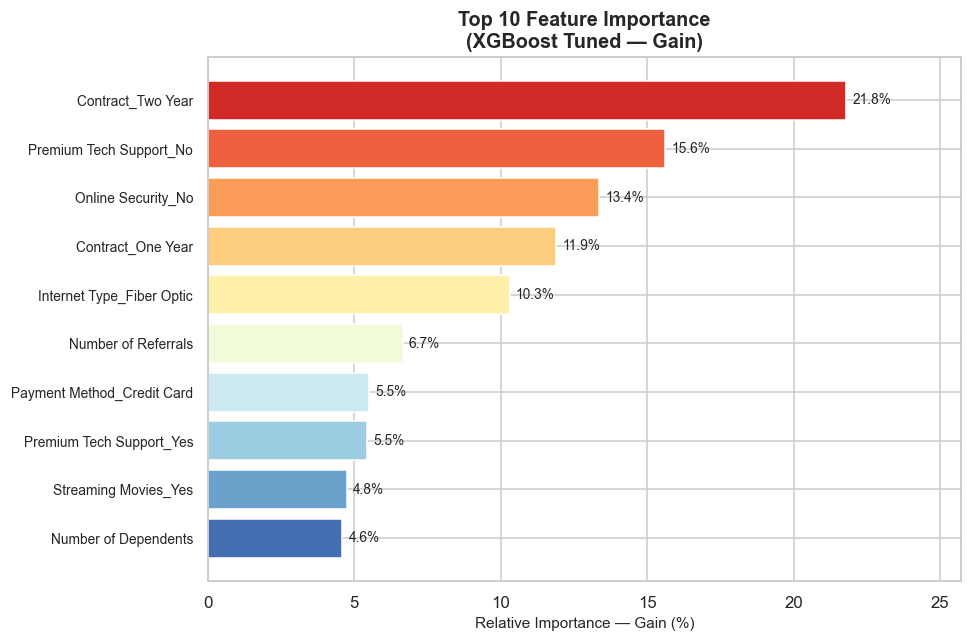

In [25]:
fig, ax = plt.subplots(figsize=(9, 6))

palette = sns.color_palette("RdYlBu_r", len(df_gain))
bars = ax.barh(
    df_gain["Feature"][::-1],
    df_gain["gain"][::-1],
    color=palette
)

ax.bar_label(bars, labels=[f"{v:.1f}%" for v in df_gain["gain"][::-1]],
             padding=4, fontsize=9)
ax.set_xlabel("Relative Importance — Gain (%)", fontsize=10)
ax.set_title("Top 10 Feature Importance\n(XGBoost Tuned — Gain)", fontweight="bold", fontsize=13)
ax.set_xlim(0, df_gain["gain"].max() * 1.18)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig("feature_importance_gain.png", bbox_inches="tight")
plt.show()

### 16.3 Perbandingan Tiga Jenis Importance

Menampilkan weight, gain, dan cover berdampingan membantu mendeteksi apakah sebuah fitur sering dipakai (weight tinggi) tetapi tidak terlalu informatif (gain rendah), atau jarang dipakai namun sangat diskriminatif ketika dipakai (gain tinggi, weight rendah).

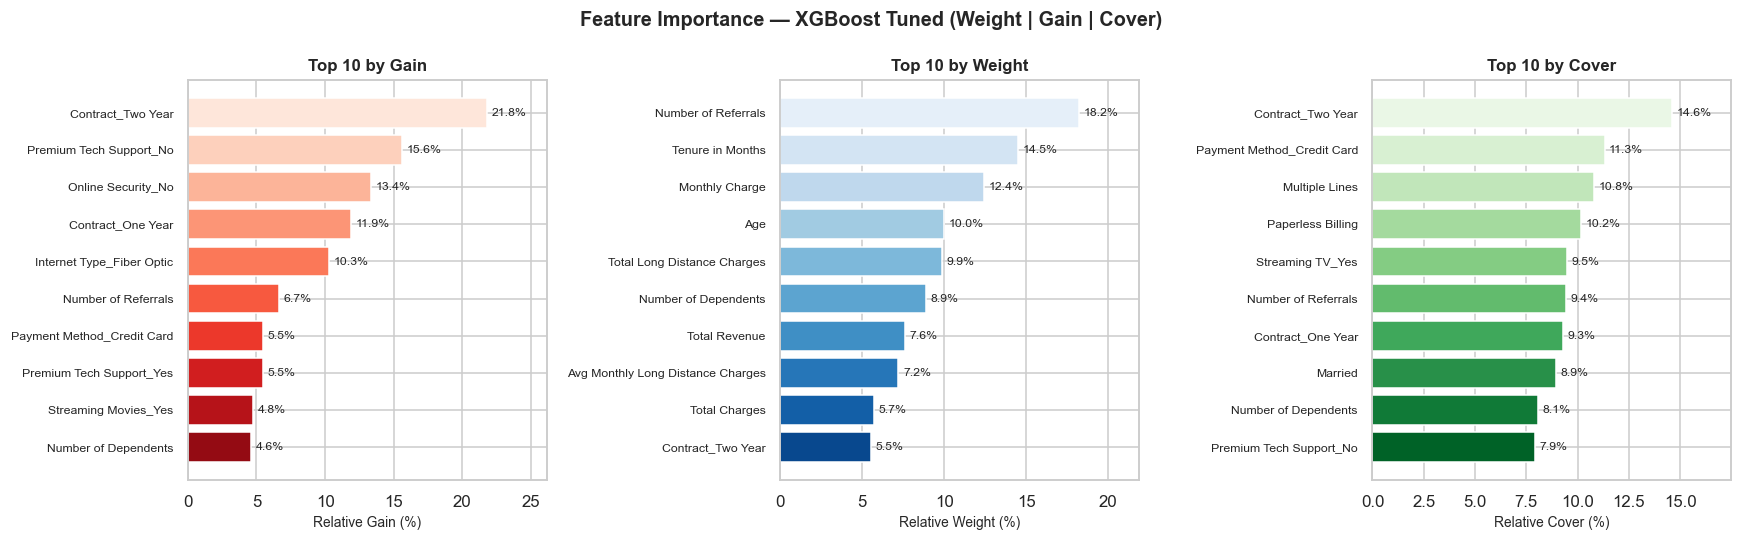

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = [
    (df_gain,   "gain",   "Gain",   sns.color_palette("Reds_r",  10)),
    (df_weight, "weight", "Weight", sns.color_palette("Blues_r", 10)),
    (df_cover,  "cover",  "Cover",  sns.color_palette("Greens_r",10)),
]

for ax, (df, col, label, pal) in zip(axes, configs):
    bars = ax.barh(df["Feature"][::-1], df[col][::-1], color=pal)
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in df[col][::-1]],
                 padding=3, fontsize=8)
    ax.set_title(f"Top 10 by {label}", fontweight="bold", fontsize=11)
    ax.set_xlabel(f"Relative {label} (%)", fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlim(0, df[col].max() * 1.2)

plt.suptitle("Feature Importance — XGBoost Tuned (Weight | Gain | Cover)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("feature_importance_comparison.png", bbox_inches="tight")
plt.show()

### 16.4 Interpretasi Feature Importance

Cetak ringkasan fitur terpenting beserta kemungkinan interpretasi bisnisnya.

In [27]:
print("=" * 60)
print("INTERPRETASI TOP 10 FITUR (berdasarkan Gain)")
print("=" * 60)
for rank, row in df_gain.iterrows():
    print(f"{rank+1:2d}. {row["Feature"]:<40} {row["gain"]:5.1f}%")

print()
print("Catatan:")
print("  Gain tinggi = fitur sangat membantu model membedakan churn vs tidak.")
print("  Fitur dengan gain tertinggi sebaiknya diprioritaskan")
print("  dalam strategi retensi pelanggan.")

INTERPRETASI TOP 10 FITUR (berdasarkan Gain)
 1. Contract_Two Year                         21.8%
 2. Premium Tech Support_No                   15.6%
 3. Online Security_No                        13.4%
 4. Contract_One Year                         11.9%
 5. Internet Type_Fiber Optic                 10.3%
 6. Number of Referrals                        6.7%
 7. Payment Method_Credit Card                 5.5%
 8. Premium Tech Support_Yes                   5.5%
 9. Streaming Movies_Yes                       4.8%
10. Number of Dependents                       4.6%

Catatan:
  Gain tinggi = fitur sangat membantu model membedakan churn vs tidak.
  Fitur dengan gain tertinggi sebaiknya diprioritaskan
  dalam strategi retensi pelanggan.
